#  Sequence & RNNs

###  **DSBA 6165: AI & Deep Learning**
### Minwoo "Jake" Lee

## Goal

The goal of this lab activity is practicing sequence and language models. We practice to build a recurrent neural networks and apply to text data.

**Before start, you need to install pydot, graphviz, and nltk, then restart the kernel.**
You can the following command for it.

> pip install pydot
<br/>
> pip install graphviz
<br/>
> pip install nltk

In [1]:
!pip3 install pydot
!pip3 install graphviz
!pip3 install nltk

Let us first import the libraries we are going to use. TensorFlow for DL models, matplotlib and seaborn for plotting data/results, numpy and pandas for data handling.

In [2]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, datasets
print("TF version:", tf.__version__)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import warnings

%matplotlib inline

TF version: 2.20.0


# Sequence Model

Let us create data with 4 samples in a window sliding one step at a time.

![](https://webpages.charlotte.edu/mlee173/teach/ml/images/class/AIDL-Lab9_features.png)

In [3]:
embedding = 4   # embedding dimension for autoregressive model T = 1000
                # generate a total of 1000 points
T = 1000
time = np.arange(0,T)
x = np.sin(0.01 * time) + 0.2 * np.random.normal(size=T)

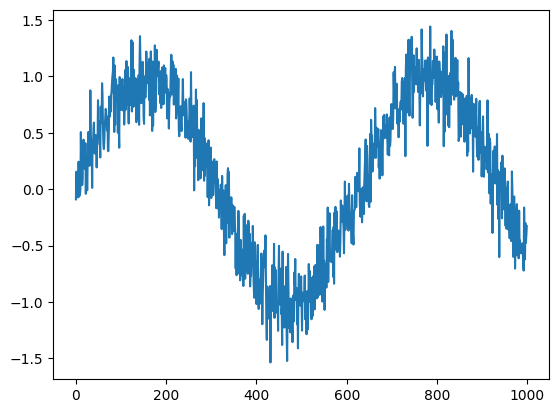

In [4]:
plt.plot(time, x);

In [5]:
features = np.zeros((T-embedding, embedding))
for i in range(embedding):
    features[:,i] = x[i:T-embedding+i]
labels = x[embedding:]

ntrain = 600
x_train, t_train = features[:ntrain,:], labels[:ntrain]
x_test, t_test = features[ntrain:,:], labels[ntrain:]

### TODO 1

1. Create a simple neural network model with the following :
      * Input layer with 4 input features
      * Three hidden layers with 10 units each and ReLU activation function having kernel_initializer as "glorot_normal"
      * Output layer with 1 unit and no activation function  having kernel_initializer as "glorot_normal"
      
2. Print the model summary
3. Using `compile`, prepare your model to have "Adam" as an `optimizer`, have a `loss` function to be "mse" and `metrics` as 'mse' and 'mae'.


In [ ]:
# TODO














Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │            50 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 281 (1.10 KB)

 Trainable params: 281 (1.10 KB)

 Non-trainable params: 0 (0.00 B)

### TODO 2
1. Using `fit`, train the model with training data (`x_train` and `t_train`) for 10 epochs, and `validation_data` be a tuple of `x_test` and `t_test`.

In [ ]:
# TODO






Epoch 1/10


19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.4978 - mae: 0.6276 - mse: 0.4978 - val_loss: 0.4287 - val_mae: 0.5554 - val_mse: 0.4287
Epoch 2/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.4373 - mae: 0.5835 - mse: 0.4373 - val_loss: 0.3795 - val_mae: 0.5201 - val_mse: 0.3795
Epoch 3/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.3499 - mae: 0.5157 - mse: 0.3499 - val_loss: 0.3099 - val_mae: 0.4661 - val_mse: 0.3099
Epoch 4/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.2458 - mae: 0.4204 - mse: 0.2458 - val_loss: 0.2259 - val_mae: 0.3934 - val_mse: 0.2259
Epoch 5/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1424 - mae: 0.3058 - mse: 0.1424 - val_loss: 0.1423 - val_mae: 0.3072 - val_mse: 0.1423
Epoch 6/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0845 - mae: 0.2338 - mse: 0.0845 - val_loss: 0.0787 - val_mae: 0.2250 - val_mse: 0.0787
Epoch 7/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0567 - mae: 0.1925 - mse: 0.0567 - val_loss: 0.0579 - val_mae:

### TODO 3

Now we have to create a **plot_res** function which plots the time-series data and an estimate of the data based on embedding technique
1. This function has four arguments: `time`, `x`, `estimates`, and `embedding`.
1. Using `plt.plot` plot the time-series data stored in the `x` array against the corresponding `time` steps stored in the time array and `label` the line as "data"
1. Using `plt.plot` plots the estimates of the time-series data stored in the `estimates` array against the corresponding time steps stored in the time array, but only for **time steps after the embedding** index, and `label` the line as "estimate"
1. end the function using `plt.legend()`

In [ ]:
# TODO





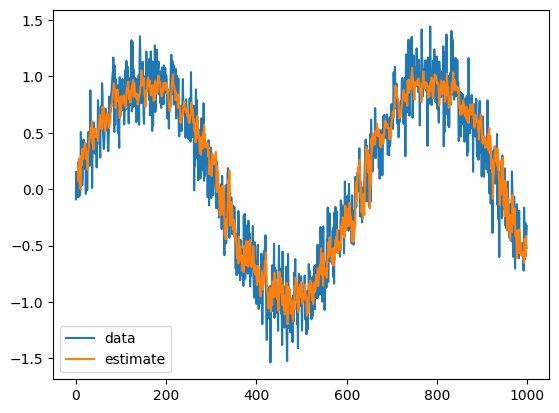

In [9]:
estimates = model(features)
plot_res(time, x, estimates, embedding)

## Multistep Prediction

As in the textbook, we can reuse the previous predictions to predict the following steps after stop feeding the data, thus

$$
\begin{split}\hat{x}_{605} = f(x_{601}, x_{602}, x_{603}, x_{604}), \\
\hat{x}_{606} = f(x_{602}, x_{603}, x_{604}, \hat{x}_{605}), \\
\hat{x}_{607} = f(x_{603}, x_{604}, \hat{x}_{605}, \hat{x}_{606}),\\
\hat{x}_{608} = f(x_{604}, \hat{x}_{605}, \hat{x}_{606}, \hat{x}_{607}),\\
\hat{x}_{609} = f(\hat{x}_{605}, \hat{x}_{606}, \hat{x}_{607}, \hat{x}_{608}),\\
\ldots\end{split}
$$


### TODO 4

Now we have to perform time series forecasting using a model that takes embedding lagged values of the time series as input and plot the results.
1. Create a variable called `predictions` and fill it with a numpy array of zeros the same size as the `estimates` array.
1. Now set first `(ntrain - embedding)` values of predictions equal to the first `(ntrain - embedding)` values of `estimates`
1. write a for loop which run from range of `(ntrain - embedding)` to `(T - embedding)`
    * In each iteration, The model should predict the next value based on the previous `embedding` values. The predicted value should stored in the predictions array. Also using `reshape` function, reshape it to (1,-1).
1. Exit the loop and plot the results using `plot_res` function which created above
    * HINT: plot the true values (x), the predicted values (predictions), and the embedding used by the model and time.

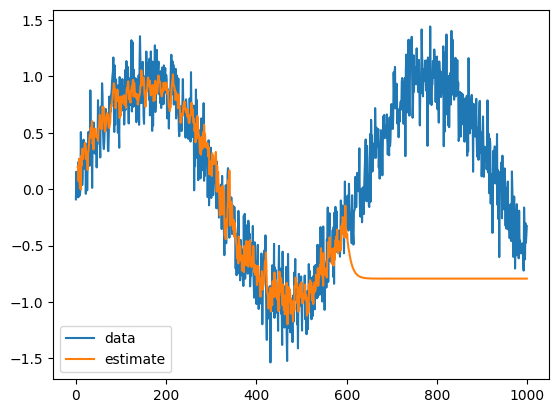

In [ ]:
# TODO







As we observed above, the predictions decay a constant value after a few steps because of the accumulated errors. Now, let us see how difficult $k$-step-ahead predictions are.

(935, 65)


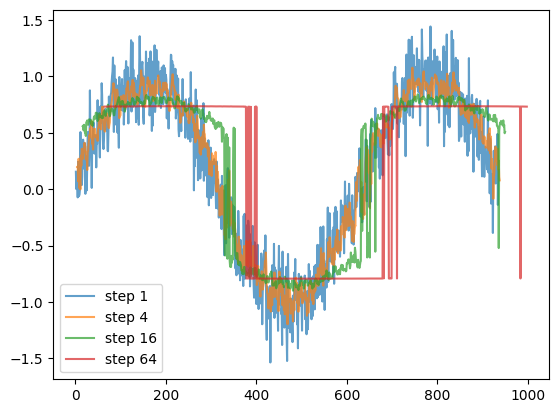

In [11]:
# based on the textbook code
# produce the k-step prediction
def k_step_pred(k, x, embedding, T):
    features = np.zeros((T-k, k))
    for i in range(embedding):
        features[:,i] = x[i:T-k+i]
    for i in range(embedding, k):
        features[:,i] = model(features[:,(i-embedding):i]).numpy().reshape((-1))
    return features

k = 65
preds = k_step_pred(k, x, embedding, T)
print(preds.shape)
for i in (1, 4, 16, 64):
    plt.plot(time[i:T-k+i], preds[:,i], label=('step ' + str(i)), alpha=0.7)
plt.legend();

# Language Model

## Text Data

Now, we will play with the text of H.G. Wells' novel "The Time Machine" (http://www.gutenberg.org/ebooks/35/). This book contains only over 30,000 words for us to play with here.

![](https://www.gutenberg.org/cache/epub/35/pg35.cover.medium.jpg)

Let us save the text "The Time Machine" to a local file named "timemachine.txt" from the Project Gutenberg website. The text file is located in this URL.

In [12]:
file_url = "https://www.gutenberg.org/files/35/35-0.txt"

### TODO 5

1. Using the `requests` library [reference_link](https://pypi.org/project/requests), send an HTTP GET request to the URL specified in url. use `allow_redirects=True` argument which allows redirects to be followed automatically.
1. open a file called "timemachine.txt" in binary write mode ('wb'), and using `write` write the contents of the server's response (`r.content`) to the file.

In [ ]:
import requests
# TODO



184747

1. Using `with open` to open the file "timemachine.txt" in the current directory with UTF-8 encoding, and assigns a file object "f" to it. Specifying encoding='utf-8' ensures compatibility across operating systems.
1. Read the entire contents of the file into the `text_data` variable using `f.read()`, then print the total character count and the first 100 characters as a preview.

In [ ]:
# TODO




Length: 179791
*** START OF THE PROJECT GUTENBERG EBOOK 35 ***




The Time Machine

An Invention

by H. G. Wells




## Preprocessing

We can use `re` regular expression library to first convert non-alphabetical characters space and then convert all letters to lower case. Follow the codes below ask questions if you need further help.  

In [15]:
import re

text = re.sub('[^A-Za-z]+', ' ', text_data).lower()

print(text_data[:100])
print("\n\n")
print(text[:100])

*** START OF THE PROJECT GUTENBERG EBOOK 35 ***




The Time Machine

An Invention

by H. G. Wells





 start of the project gutenberg ebook the time machine an invention by h g wells contents i introduc


### Tokenizing
Tokenization is breaking the raw text into small chunks. Tokenization breaks the raw text into words, sentences called tokens. These tokens help in understanding the context or developing the model for the NLP. The tokenization helps in interpreting the meaning of the text by analyzing the sequence of the words.
For example, the text “It is raining” can be tokenized into ‘It’, ‘is’, ‘raining’

There are different methods and libraries available to perform tokenization. NLTK, Gensim, Keras are some of the libraries that can be used to accomplish the task.

There are various tokenization techniques available which can be applicable based on the language and purpose of modeling. Below are a few of the tokenization techniques used in NLP.

1. Word tokenization. This method breaks text down into individual words. It's the most common approach and is particularly effective for languages with clear word boundaries like English.
2. Character tokenization. Here, the text is segmented into individual characters. This method is beneficial for languages that lack clear word boundaries or for tasks that require a granular analysis, such as spelling correction.
3. Subword tokenization. Striking a balance between word and character tokenization, this method breaks text into units that might be larger than a single character but smaller than a full word. For instance, "Chatbots" could be tokenized into "Chat" and "bots". This approach is especially useful for languages that form meaning by combining smaller units or when dealing with out-of-vocabulary words in NLP tasks.

Here are some instructions for manually tokenizing a text:
  * Identify the type of tokenization you want to use: There are different types of tokenization such as word-based, sentence-based, or character-based. Choose the type of tokenization that is most appropriate for your task.
  * Remove any unwanted characters: Before you begin tokenizing, remove any unwanted characters such as punctuation marks or special characters that are not part of the text (See Preprocessing above).
  * Identify the boundary of the tokens: For word-based tokenization, the boundary is usually a space or a punctuation mark. For sentence-based tokenization, the boundary is usually a period, question mark, or exclamation mark.
  * Use a delimiter to separate tokens: Once you have identified the boundary of the tokens, use a delimiter such as a space or a comma to separate the tokens.
  * Handle special cases: There may be cases where a word or phrase should not be split into separate tokens. For example, "New York" should be treated as a single token in most cases. You may need to manually identify and handle such cases.



For character level tokenization, we can simply convert the string text to list as below.

In [16]:
list(text)[:10]

[' ', 's', 't', 'a', 'r', 't', ' ', 'o', 'f', ' ']

### TODO 6
1. Run word-based tokenization using `split()` method. Show the first 10 words from the word tokens.

In [ ]:
# TODO


['start',
 'of',
 'the',
 'project',
 'gutenberg',
 'ebook',
 'the',
 'time',
 'machine',
 'an']

Note that manual tokenization can be time-consuming and may not be suitable for large volumes of text. There are automated tools and libraries available for tokenization that can save time and improve accuracy. NLTK is one of those tools, so let us play with it. Let us first import nltk and download `punkt` sentence tokenizer.  

In [18]:
import nltk
#nltk.download('popular')
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to C:\Users\David
[nltk_data]     Bayha\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to C:\Users\David
[nltk_data]     Bayha\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

### TODO 7

1. Tokenize a text using `nltk.word_tokenize` and store to a variable called `tokens`.

In [ ]:
# TODO


Now we can see the first 10 tokens, which is identical to the previous results.

In [20]:
tokens[:10]

['start',
 'of',
 'the',
 'project',
 'gutenberg',
 'ebook',
 'the',
 'time',
 'machine',
 'an']

Now, let us examine the distributions of the tokens using `nltk.FreqDist`, which shows the freqencies of each word in the text. We can repeat this for bigrams and trigrams (two or three consecutive words).  

In [21]:
fdist = nltk.FreqDist(tokens)
fdist

FreqDist({'the': 2287, 'i': 1268, 'and': 1245, 'of': 1165, 'a': 819, 'to': 684, 'was': 552, 'in': 545, 'that': 443, 'my': 441, ...})

In [22]:
fdist2 = nltk.FreqDist(nltk.bigrams(tokens))
fdist2

FreqDist({('of', 'the'): 311, ('in', 'the'): 173, ('i', 'had'): 130, ('i', 'was'): 112, ('and', 'the'): 109, ('the', 'time'): 106, ('it', 'was'): 99, ('to', 'the'): 85, ('as', 'i'): 78, ('of', 'a'): 73, ...})

In [23]:
fdist3 = nltk.FreqDist(nltk.trigrams(tokens))
fdist3

FreqDist({('the', 'time', 'traveller'): 63, ('the', 'time', 'machine'): 30, ('the', 'medical', 'man'): 24, ('it', 'seemed', 'to'): 16, ('it', 'was', 'a'): 15, ('here', 'and', 'there'): 15, ('seemed', 'to', 'me'): 14, ('i', 'did', 'not'): 14, ('i', 'saw', 'the'): 13, ('the', 'white', 'sphinx'): 12, ...})

If we plot the frequencies in an original scae, we can see the following curve, hard to read. It kind of tells us that there are few words are highly frequent than the rest of words. You may notice what are they.

<Axes: xlabel='Samples', ylabel='Counts'>

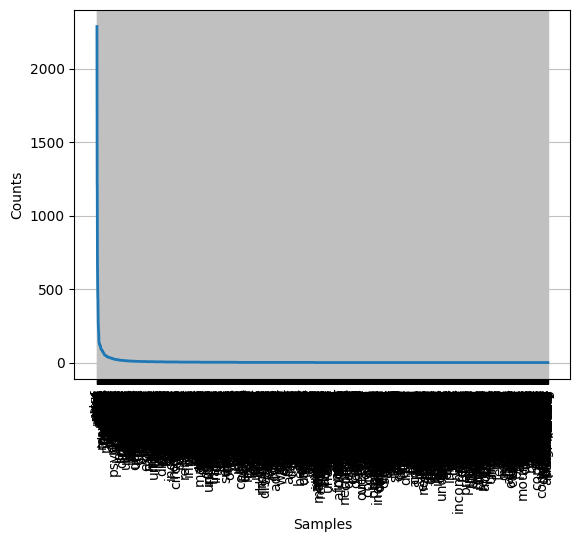

In [24]:
fdist.plot()

Now, let us create log-log plot that convert both x and y axis into log scale to see the relation. From this plot, we can observe the phenomena called Zipf's law, saying the frequency $n_i$ of the $i^\text{th}$ most frequent word is
$$
n_i \propto \frac{1}{i^\alpha}
$$
In log-scale, we can rewrite this as
$$
\log n_i = -\alpha \log i + c,
$$
which are exactly what we observe from the plot below.

C:\Users\David Bayha\AppData\Local\Temp\ipykernel_93584\3428176075.py:2: RuntimeWarning: divide by zero encountered in log
  plt.plot(np.log(np.arange(len(x))),


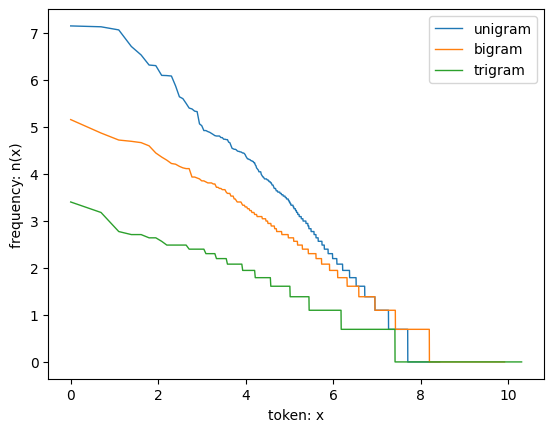

In [25]:
def log_log_plot(x, slabel):
    plt.plot(np.log(np.arange(len(x))),
             np.log(np.sort(x)[::-1]),
             linewidth=1, label=slabel)


unigram_freqs = [freq for token, freq in fdist.items()]
bigram_freqs = [freq for token, freq in fdist2.items()]
trigram_freqs = [freq for token, freq in fdist3.items()]
# x = np.log(np.arange(len(unigram_freqs)))
log_log_plot(unigram_freqs, 'unigram')
log_log_plot(bigram_freqs, 'bigram')
log_log_plot(trigram_freqs, 'trigram')
plt.xlabel('token: x')
plt.ylabel('frequency: n(x)')
plt.legend()


# Recurrent Neural Networks

#### Initializing and Preparing Gender Classification Data from Names: Create separate lists for male and female names, initialize corresponding labels to 0, and then concatenate the names and labels into single lists for input (X) and output (y) in a gender classification task.


### TODO 8

1. Create a variable `male_names` and extract male names from the names corpus using the `words("male.txt")` function
1. Creates a list `male_labels` with a length equal to the number of male names, and initializes each element to 0.
    * Hint: Multiplying a list duplicate the element by the constant. For instance, [5] * 5 => [5, 5, 5, 5, 5]
1. Create a variable `female_names` and extract male names from the names corpus using the `words("female.txt")` function
1. Create a list `female_labels` with a length equal to the number of female names and initialize each element to

    * Hint: Multiplying a list duplicate the element by the constant.
1. Now concatenate the `male_names` and `female_names` lists into a single list `X` of all names, and concatenate the male_labels and female_labels lists into a single list `y` of all labels.

In [ ]:
from nltk.corpus import names
nltk.download('names')

# TODO


[nltk_data] Downloading package names to C:\Users\David
[nltk_data]     Bayha\AppData\Roaming\nltk_data...
[nltk_data]   Package names is already up-to-date!


Let us check the content of data `X` and `y` by looking at the first and last 5 elements in them.

In [27]:
X[:5], y[:5], X[-5:], y[-5:]

(['Aamir', 'Aaron', 'Abbey', 'Abbie', 'Abbot'],
 [0, 0, 0, 0, 0],
 ['Zorine', 'Zsa Zsa', 'Zsazsa', 'Zulema', 'Zuzana'],
 [1, 1, 1, 1, 1])

### TODO 9

1. Using `train_test_split`, divide the data into `X_train_raw`, `X_test_raw`, `y_train`, `y_test` with `X` and `y` as inputs. Set `test_size` to 0.2 and `random_state` to 42.
2. Print the number of samples in the train and test sets using an f-string to verify the split.

In [ ]:
from sklearn.model_selection import train_test_split

# TODO




Train data: 6355, Test data: 1589


## Tokenizing

### TODO 10
1. Create a new `tokenizer` object using `Tokenizer` and set the `char_level` parameter to `True`.
1. Now let us fit the `tokenizer` we created above on the training data `X_train_raw` using `fit_on_texts()`

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer

# TODO



Now, we can look at the corpus dictionary (in this case, dictionary consists of characters), showing the mapping of characters (or words) and corresponding numbers.

In [30]:
tokenizer.word_index

{'a': 1,
 'e': 2,
 'i': 3,
 'n': 4,
 'r': 5,
 'l': 6,
 'o': 7,
 't': 8,
 's': 9,
 'd': 10,
 'y': 11,
 'm': 12,
 'h': 13,
 'c': 14,
 'b': 15,
 'u': 16,
 'g': 17,
 'k': 18,
 'v': 19,
 'j': 20,
 'f': 21,
 'p': 22,
 'w': 23,
 'z': 24,
 'x': 25,
 'q': 26,
 '-': 27,
 ' ': 28,
 "'": 29}

### TODO 11
1. Create a variable `vocab_size` and calculate the size of the vocabulary that the `tokenizer` has.
    * Hint:
        * use `len`  function for getting length of the tokenizer's word_index and add "+1"
2. Print `vocab_size` using an f-string to confirm the total number of unique tokens in the vocabulary.


In [ ]:
# TODO



Vocabulary Size: 30


### Text to Sequences
Now let us use `tokenizer` to convert the raw text data to sequences of integers.

### TODO 12
1. Create `X_train_seq` using the `texts_to_sequences()` method of the `tokenizer` to convert the raw text data `X_train_raw` into sequences of integers.
2. Print the first 5 raw names alongside their corresponding integer sequences using an f-string to verify the conversion.


In [ ]:
# TODO



['Hannibal', 'Christel', 'Johny', 'Linzy', 'Jeramie']
[[13, 1, 4, 4, 3, 15, 1, 6], [14, 13, 5, 3, 9, 8, 2, 6], [20, 7, 13, 4, 11], [6, 3, 4, 24, 11], [20, 2, 5, 1, 12, 3, 2]]


As you can see, the first line shows the first five samples of the raw text data, and the second line shows the first five integer sequences corresponding to those samples. The integer sequences are a way of representing the text data in a more compact and standardized format that can be fed into machine learning models for training and prediction since RNN models cannot deal with nonnumerical input as it is.

### Padding

Now, let us take look at the numerical sequences that we created above. Checking the lengths of each are quite variant as shown in the following figure. This can be difficult for a neural network to deal with as it expects identical size for the input. So, we consider "padding" here.

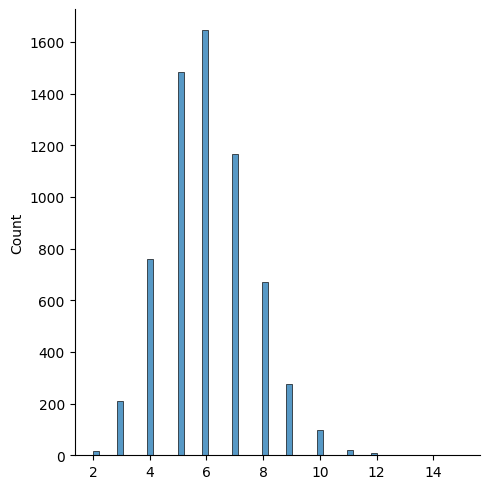

In [33]:
names_lens = [len(n) for n in  X_train_seq]
names_lens

sns.displot(names_lens)
#print(X_train[np.argmax(names_lens)])  # longest name

In [34]:
max_len = np.max(names_lens)
max_len

np.int64(15)

### TODO 13

1. Create a variable called `X_train` and use `sequence.pad_sequences()` function and pass two arguments: `X_train_seq`, and `maxlen` as `max_len`.
2. Display the first 10 samples of the padded integer sequence data using slicing notation.

In [ ]:
from tensorflow.keras.preprocessing import sequence

# TODO



array([[ 0,  0,  0,  0,  0,  0,  0, 13,  1,  4,  4,  3, 15,  1,  6],
       [ 0,  0,  0,  0,  0,  0,  0, 14, 13,  5,  3,  9,  8,  2,  6],
       [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0, 20,  7, 13,  4, 11],
       [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  6,  3,  4, 24, 11],
       [ 0,  0,  0,  0,  0,  0,  0,  0, 20,  2,  5,  1, 12,  3,  2],
       [ 0,  0,  0,  0,  0,  0,  0,  0,  0, 10,  2,  5,  5,  7,  6],
       [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0, 18,  1,  4,  2],
       [ 0,  0,  0,  0,  0,  0,  0,  0, 14,  6,  1, 16, 10,  3,  2],
       [ 0,  0,  0,  0,  0,  0, 23,  3,  6,  6,  1, 12,  3,  4,  1],
       [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  6,  2,  4,  1]],
      dtype=int32)

### TODO 14
1. Referring to the previous TODO, create `X_test` similar to `X_train`, this time by using `X_test_raw`.
2. Convert `y_train` to numpy array.
3. Convert `y_test` to numpy array.

In [ ]:
# TODO







In [37]:
X_train.shape, X_test.shape

((6355, 15), (1589, 15))

## RNN

### TODO 15

1. Create a `rnn` model using keras.Sequential() and add following layers
    * add `layers.Embedding` having `input_dim` equal to vocab_size ,`output_dim` as EMBEDDING_DIM , `input_length` as `max_len` and keep `mask_zero` as True
    * add `SimpleRNN` which should have 16 units and uses ReLU activation function and name the layer as "RNN_layer"
    * add `Dense` which should have 16 units and uses ReLU activation function and name the layer as "dense_layer".
    * add another layer `Dense`  which should have  single unit and uses sigmoid activation function and name the layer as "output".
1. Print the summary of the model.
1. Using `compile`, prepare your model to have "adam" as an optimizer, have a loss function to be "binary_crossentropy" also it should take metrics as "accuracy".

In [ ]:
## Define the embedding dimension
EMBEDDING_DIM = 128

# TODO
## Define rnn















c:\Users\David Bayha\OneDrive\Desktop\6165_labs\6165\6165_labs\envs\lab5\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ RNN_layer (SimpleRNN)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_layer (Dense)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

**If you have not installed pydot and graphviz, please restart the kernel after installing them**

In [39]:
#!pip3 install pydot
#!pip3 install graphviz

In [40]:
from keras.utils import plot_model

rnn.build(input_shape=(None, max_len))
plot_model(rnn, show_shapes=True)

You must install graphviz (see instructions at https://graphviz.gitlab.io/download/) for `plot_model` to work.


### TODO 15-1

1. Using `fit`, train the model with training data (`X_train` and `y_train`). Keep `batch_size` as `BATCH_SIZE` and `epochs` as `EPOCHS`, `verbose` as 2 and `validation_split` as `VALIDATION_SPLIT` as defined below.

In [ ]:
## Hyperparameters
BATCH_SIZE = 128
EPOCHS = 20
VALIDATION_SPLIT = 0.2

# TODO







Epoch 1/20


40/40 - 2s - 44ms/step - accuracy: 0.7380 - loss: 0.5901 - val_accuracy: 0.7451 - val_loss: 0.5006
Epoch 2/20
40/40 - 0s - 6ms/step - accuracy: 0.7703 - loss: 0.4674 - val_accuracy: 0.7789 - val_loss: 0.4624
Epoch 3/20
40/40 - 0s - 6ms/step - accuracy: 0.7907 - loss: 0.4369 - val_accuracy: 0.7923 - val_loss: 0.4466
Epoch 4/20
40/40 - 0s - 6ms/step - accuracy: 0.7986 - loss: 0.4233 - val_accuracy: 0.7718 - val_loss: 0.4410
Epoch 5/20
40/40 - 0s - 6ms/step - accuracy: 0.8053 - loss: 0.4120 - val_accuracy: 0.7946 - val_loss: 0.4299
Epoch 6/20
40/40 - 0s - 6ms/step - accuracy: 0.8125 - loss: 0.4038 - val_accuracy: 0.7939 - val_loss: 0.4265
Epoch 7/20
40/40 - 0s - 6ms/step - accuracy: 0.8125 - loss: 0.3966 - val_accuracy: 0.8009 - val_loss: 0.4209
Epoch 8/20
40/40 - 0s - 6ms/step - accuracy: 0.8173 - loss: 0.3913 - val_accuracy: 0.8033 - val_loss: 0.4186
Epoch 9/20
40/40 - 0s - 6ms/step - accuracy: 0.8226 - loss: 0.3846 - val_accuracy: 0.8033 - val_loss: 0.4147
Epoch 10/20
40/40 - 0s - 6ms/

### TODO 15-2
1. Create `plot_learning` function that plots the training, validation loss and accuracy learning curve using the history argument. You can also refer to the previous lab session to complete this function.


In [ ]:
# TODO













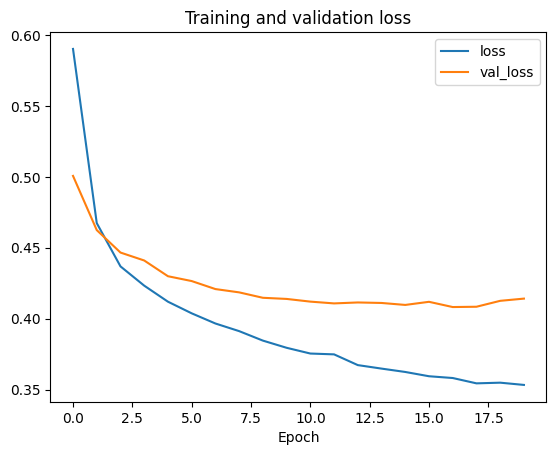

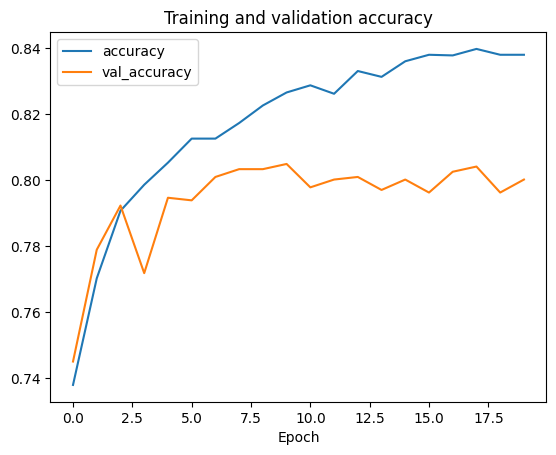

In [43]:
plot_learning(history)

## Dropout

### TODO 16



1. Define a new model `rnn2` same as `rnn` above.
1. Modify `SimpleRNN` layer to add `dropout` and `recurrent_dropout` as 0.2. `name` the layer as "RNN_layer_Dropout".
1. The rest remains the same.

In [ ]:
# TODO
## Define rnn


















Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ RNN_layer_Dropout (SimpleRNN)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_layer (Dense)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

### TODO 16-1

1. Using `fit`, train the second model with training data (`X_train` and `y_train`). Keep `batch_size` as `BATCH_SIZE` and `epochs` as `EPOCHS`, `verbose` as 2 and `validation_split` as `VALIDATION_SPLIT` as defined above.

In [ ]:
# TODO







Epoch 1/20


40/40 - 2s - 55ms/step - accuracy: 0.7032 - loss: 0.6488 - val_accuracy: 0.7388 - val_loss: 0.5724
Epoch 2/20
40/40 - 0s - 6ms/step - accuracy: 0.7573 - loss: 0.5089 - val_accuracy: 0.7498 - val_loss: 0.4856
Epoch 3/20
40/40 - 0s - 6ms/step - accuracy: 0.7644 - loss: 0.4626 - val_accuracy: 0.7687 - val_loss: 0.4707
Epoch 4/20
40/40 - 0s - 7ms/step - accuracy: 0.7783 - loss: 0.4496 - val_accuracy: 0.7750 - val_loss: 0.4685
Epoch 5/20
40/40 - 0s - 6ms/step - accuracy: 0.7724 - loss: 0.4471 - val_accuracy: 0.7742 - val_loss: 0.4614
Epoch 6/20
40/40 - 0s - 6ms/step - accuracy: 0.7870 - loss: 0.4398 - val_accuracy: 0.7734 - val_loss: 0.4560
Epoch 7/20
40/40 - 0s - 6ms/step - accuracy: 0.7886 - loss: 0.4398 - val_accuracy: 0.7773 - val_loss: 0.4566
Epoch 8/20
40/40 - 0s - 6ms/step - accuracy: 0.7911 - loss: 0.4348 - val_accuracy: 0.7797 - val_loss: 0.4545
Epoch 9/20
40/40 - 0s - 6ms/step - accuracy: 0.7927 - loss: 0.4329 - val_accuracy: 0.7742 - val_loss: 0.4539
Epoch 10/20
40/40 - 0s - 6ms/

### TODO 16-2

1. Plot both the training and validation loss, training and validation accuracy curves using the function defined above.

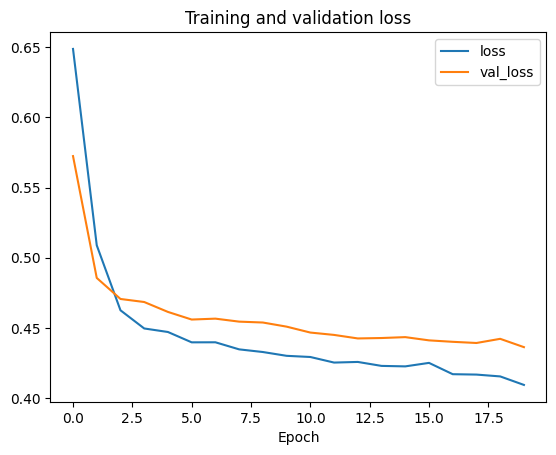

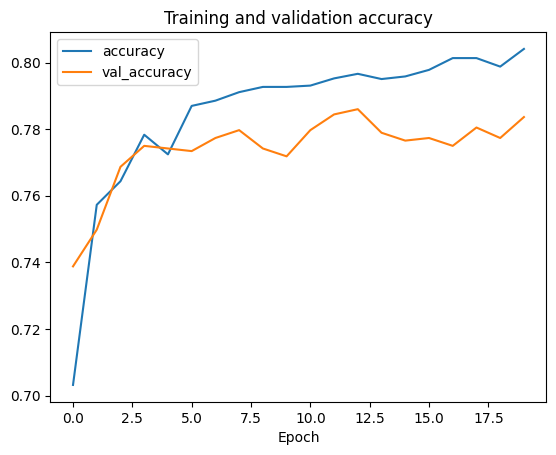

In [ ]:
# TODO


### TODO 16-3
1. Evaluate `rnn` using `evaluate` on X_test and y_test keeping batch_size as BATCH_SIZE and verbose as 2


In [ ]:
# TODO


13/13 - 0s - 4ms/step - accuracy: 0.8074 - loss: 0.4204


[0.4203883409500122, 0.8074260354042053]

1. Evaluate `rnn2` using `evaluate` on X_test and y_test keeping batch_size as BATCH_SIZE and verbose as 2


In [ ]:
# TODO


13/13 - 0s - 6ms/step - accuracy: 0.7898 - loss: 0.4333


[0.4333106577396393, 0.7898049354553223]

## Stacking

### TODO 17
1. Define a new model rnn3 same as rnn2 above with these changes.
    * `layers.Embedding` remains same
    * add `layers.SimpleRNN` same as rnn2 add aditional argument "return_sequences" as True
    * add `layers.SimpleRNN` same as rnn2
    * Remove the `layers.Dense` with 16 units
    * add `layers.Dense` with single unit remains same
Rwast remains the same


In [ ]:
# TODO
## Define model




























Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ RNN_layer_1 (SimpleRNN)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ RNN_layer_2 (SimpleRNN)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

### TODO 17-1

1. Using `fit`, train the second model with training data (`X_train` and `y_train`). Keep `batch_size` as `BATCH_SIZE` and `epochs` as `EPOCHS`, `verbose` as 2 and `validation_split` as `VALIDATION_SPLIT` as defined above.
1. Plot learning curve using `plot_learning`.

Epoch 1/20
40/40 - 3s - 63ms/step - accuracy: 0.6520 - loss: 0.6173 - val_accuracy: 0.6924 - val_loss: 0.5589
Epoch 2/20
40/40 - 0s - 5ms/step - accuracy: 0.7120 - loss: 0.5321 - val_accuracy: 0.7443 - val_loss: 0.4918
Epoch 3/20
40/40 - 0s - 6ms/step - accuracy: 0.7526 - loss: 0.4875 - val_accuracy: 0.7624 - val_loss: 0.4687
Epoch 4/20
40/40 - 0s - 5ms/step - accuracy: 0.7675 - loss: 0.4700 - val_accuracy: 0.7789 - val_loss: 0.4573
Epoch 5/20
40/40 - 0s - 5ms/step - accuracy: 0.7710 - loss: 0.4669 - val_accuracy: 0.7828 - val_loss: 0.4522
Epoch 6/20
40/40 - 0s - 7ms/step - accuracy: 0.7803 - loss: 0.4547 - val_accuracy: 0.7789 - val_loss: 0.4472
Epoch 7/20
40/40 - 0s - 9ms/step - accuracy: 0.7840 - loss: 0.4487 - val_accuracy: 0.7891 - val_loss: 0.4388
Epoch 8/20
40/40 - 0s - 8ms/step - accuracy: 0.7815 - loss: 0.4487 - val_accuracy: 0.7891 - val_loss: 0.4391
Epoch 9/20
40/40 - 0s - 8ms/step - accuracy: 0.7836 - loss: 0.4460 - val_accuracy: 0.7860 - val_loss: 0.4352
Epoch 10/20
40/40 

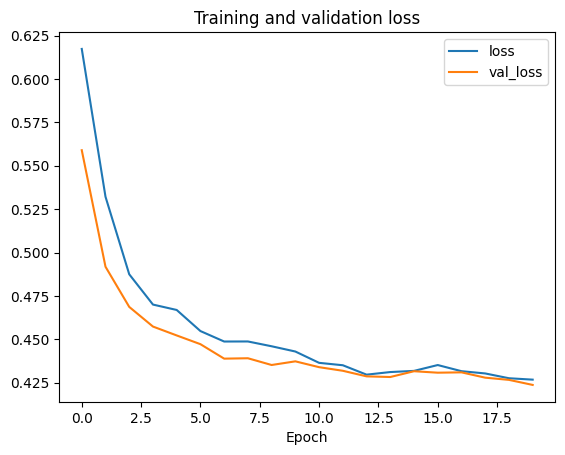

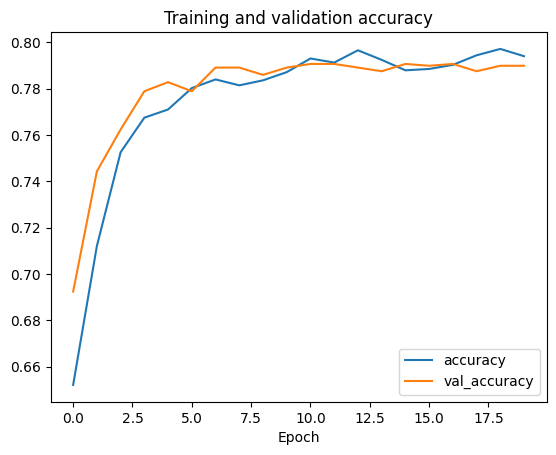

In [ ]:
# TODO









### TODO 17-2

1. `evaluate` model on test data (`X_test` and `y_test`) keeping `verbose` as 2 and `bath_size`as BATCH_SIZE

In [ ]:
# TODO


13/13 - 0s - 5ms/step - accuracy: 0.8043 - loss: 0.4227


[0.42268308997154236, 0.8042794466018677]